In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import torch
import pyro
from matplotlib import pyplot as plt
import squidpy as sq
import seaborn as sns

import dataset, configs

import scKI

from torch.utils.data import random_split
from torch_geometric.data import DataLoader


/opt/conda/envs/attn/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/conda/envs/attn/lib/python3.9/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/opt/conda/envs/attn/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [2]:
%load_ext autoreload
%autoreload 2

In [33]:
from torch.utils.data import Dataset
from sklearn.neighbors import NearestNeighbors


class CellNeighbourDataset(Dataset):
    # -------------------------------------------------------------
    def __init__(self, adata, k: int = 8):
        super().__init__()
        self.adata       = adata
        self.k           = k

        # -------- expressions & clusters -------------------------
        X = adata.X.A if hasattr(adata.X, "A") else adata.X        # dense (n, d)
        self.x_mat = torch.as_tensor(X, dtype=torch.float32)       # full matrix
        self.clu   = torch.as_tensor(
                        adata.obs['leiden'].values.astype(int), dtype=torch.long
                     )

        # -------- spatial k-NN graph -----------------------------
        coords = adata.obsm["spatial"].astype(float)               # (n, 2)
        nbrs   = NearestNeighbors(n_neighbors=k + 1,
                                  algorithm="ball_tree").fit(coords)
        dists, idxs = nbrs.kneighbors(coords)                      # (n, k+1)

        self.nbr_idx  = idxs[:, 1:]                                # drop self
        self.nbr_dist = dists[:, 1:]

    # -------------------------------------------------------------
    def __len__(self):
        return self.x_mat.shape[0]

    # -------------------------------------------------------------
    def __getitem__(self, idx: int):
        # focal cell
        x_focal   = self.x_mat[idx].unsqueeze(0)                   # [1, d]
        clu_focal = self.clu[idx].unsqueeze(0)                     # [1]

        # neighbours
        n_idx     = self.nbr_idx[idx]                              # (k,)
        x_nb      = self.x_mat[n_idx]                              # [k, d]
        e_attr    = torch.as_tensor(self.nbr_dist[idx],
                                    dtype=torch.float32)           # [k]

        return {
            "x":         x_focal,          # [n=1, d]
            "neighbors": x_nb,             # [k, d]
            "edge_attr": e_attr,           # [k]
            "cluster":   clu_focal,        # [n=1]
        }


In [3]:
adata = sc.read_h5ad('./data/synthetic_interaction.h5ad')
adata.X = adata.layers['counts'].copy()
interaction_df = pd.read_csv('./data/interaction.csv')

/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [4]:
# Filter out cells belonging to Leiden cluster 0
print("Shape before filtering:", adata.shape)
adata = adata[adata.obs['leiden'] != '0']
print("Shape after filtering:", adata.shape)

Shape before filtering: (20000, 500)
Shape after filtering: (20000, 500)


In [36]:
interaction_df

,receptor_cell,receptor_subtype,interaction_type,sender_cell,radius_of_effect
0,4,4_sub0,neutral,NaN,NaN
1,1,1_sub0,neutral,NaN,NaN
2,2,2_sub0,neutral,NaN,NaN
3,1,1_sub1,interaction,4.0,20.0
4,2,2_sub1,interaction,1.0,10.0
5,0,0_sub0,neutral,NaN,NaN


In [37]:
ds = CellNeighbourDataset(adata, k=25)
train_dl = DataLoader(ds, batch_size=64, shuffle=True)
val_dl = train_dl

/opt/conda/envs/attn/lib/python3.9/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [38]:
N, k = ds.nbr_idx.shape
sub_prefix_arr = adata.obs["subtype"].astype(str).str.split("_").str[0].to_numpy()

# ------------------------------------------------------------------
# ❶  build prefix → list-of-indices once  (Python loop, O(N))
from collections import defaultdict
prefix_to_idx = defaultdict(list)
for i, p in enumerate(sub_prefix_arr):
    prefix_to_idx[p].append(i)

# ------------------------------------------------------------------
# ❷  flags to fill
sending   = np.zeros(N, dtype=bool)
receiving = np.zeros_like(sending)

# ------------------------------------------------------------------
# ❸  fast helper views
nbr_idx  = ds.nbr_idx           # (N, k)  int
nbr_dist = ds.nbr_dist          # (N, k)  float

# ------------------------------------------------------------------
# ❹  iterate once per interaction row  (O(#usable rows) ≪ N·k)
usable = (
    interaction_df
      .query("interaction_type == 'interaction' and sender_cell.notna()")
      .assign(sender_cell   = lambda d: d.sender_cell.astype(int).astype(str),
              receptor_cell = lambda d: d.receptor_cell.astype(int).astype(str))
)

for s_pref, r_pref, R in usable[["sender_cell", "receptor_cell", "radius_of_effect"]].itertuples(index=False):
    send_idx = np.array(prefix_to_idx.get(s_pref, []), dtype=int)      # (m,)
    if send_idx.size == 0:                                             # no sender of that prefix
        continue

    neigh_idx   = nbr_idx[send_idx]            # (m, k)
    neigh_dist  = nbr_dist[send_idx]           # (m, k)

    # mask: neighbour is right receptor subtype **and** within radius
    hit = (sub_prefix_arr[neigh_idx] == r_pref) & (neigh_dist <= R)    # bool (m, k)

    # mark senders that hit at least one valid receptor
    sender_hits = hit.any(axis=1)
    sending[send_idx[sender_hits]] = True

    # gather all receptor indices that satisfy both conditions
    receiving_idx = neigh_idx[hit]
    receiving[receiving_idx] = True

# ------------------------------------------------------------------
# ❺  write results back to AnnData
adata.obs["sending"]   = sending
adata.obs["receiving"] = receiving

/var/tmp/ipykernel_869802/3303441541.py:51: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["sending"]   = sending
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [39]:
is_sub0 = adata.obs["subtype"].str.endswith("sub0")
is_sub1 = adata.obs["subtype"].str.endswith("sub1")

viol_sub0 = adata.obs.loc[is_sub0 &  adata.obs["receiving"]].index
viol_sub1 = adata.obs.loc[is_sub1 & ~adata.obs["receiving"]].index

if len(viol_sub0) or len(viol_sub1):
    if len(viol_sub0):
        print("❌  sub0 cells incorrectly flagged as receiving=True:")
        print(list(viol_sub0))
    if len(viol_sub1):
        print("❌  sub1 cells incorrectly flagged as receiving=False:")
        print(list(viol_sub1))
    raise AssertionError("Receiving-flag rule violated for the indices above.")
else:
    print("✅  All subtype–receiving rules satisfied.")

✅  All subtype–receiving rules satisfied.


In [5]:
# Dataset specs
k = 15
sigma=10
n_subgraphs = 15

graph_data = dataset.XeniumDataset(
    adatas=[adata], 
    n_subgraphs=n_subgraphs, 
    k=k,
    is_weighted=True,
    sigma=sigma,
)

# train_data, val_data = random_split(graph_data, [0.7, 0.3])
train_dl, val_dl = DataLoader(graph_data, shuffle=True), DataLoader(graph_data)

edge_median = 15.532303810119629

/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/conda/envs/attn/lib/python3.9/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.ClusterData' is deprecated, use 'loader.ClusterData' instead
  warnings.warn(out)
/opt/conda/envs/attn/lib/python3.9/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


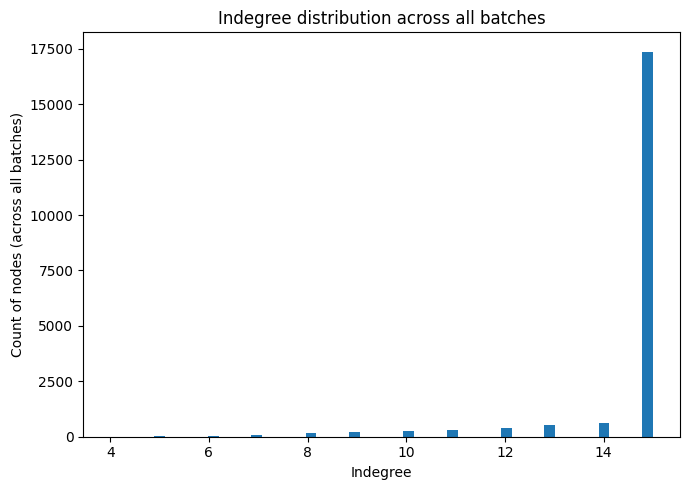

In [53]:
import torch
import matplotlib.pyplot as plt

def indegree_hist(batch):
    num_nodes = batch.x.size(0)
    dst = batch.edge_index[1]
    indeg = torch.bincount(dst, minlength=num_nodes)
    return indeg

all_indeg = []

for i, g in enumerate(graph_data):
    indeg = indegree_hist(g)
    all_indeg.append(indeg)

    if (indeg == 0).any():
        zero_idx = (indeg == 0).nonzero(as_tuple=True)[0]
        print(f"Batch {i}: zero indegree nodes = {zero_idx.tolist()} (count={len(zero_idx)})")

# Concatenate indegrees from all batches
all_indeg = torch.cat(all_indeg)

# Plot single histogram across all batches
plt.figure(figsize=(7,5))
plt.hist(all_indeg.numpy(), bins=50)
plt.xlabel("Indegree")
plt.ylabel("Count of nodes (across all batches)")
plt.title("Indegree distribution across all batches")
plt.tight_layout()
plt.show()


/opt/conda/envs/attn/lib/python3.9/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


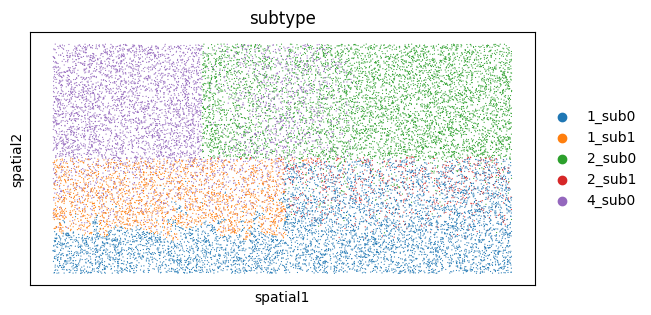

In [6]:
sq.pl.spatial_scatter(adata, color='subtype', img=False, size=5)

/opt/conda/envs/attn/lib/python3.9/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


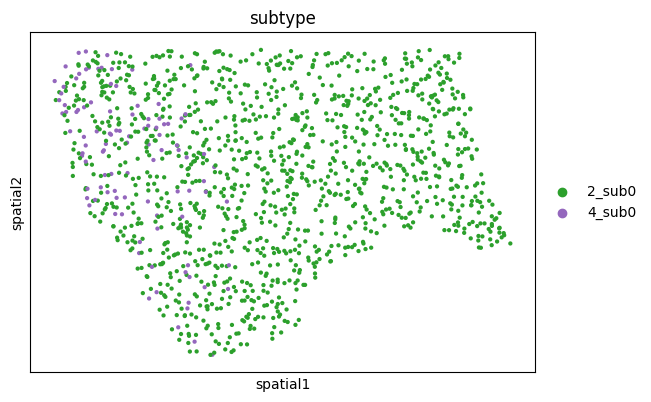

Slice 0: 0/0 sub1 cells receiving (0.00 %).


/opt/conda/envs/attn/lib/python3.9/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


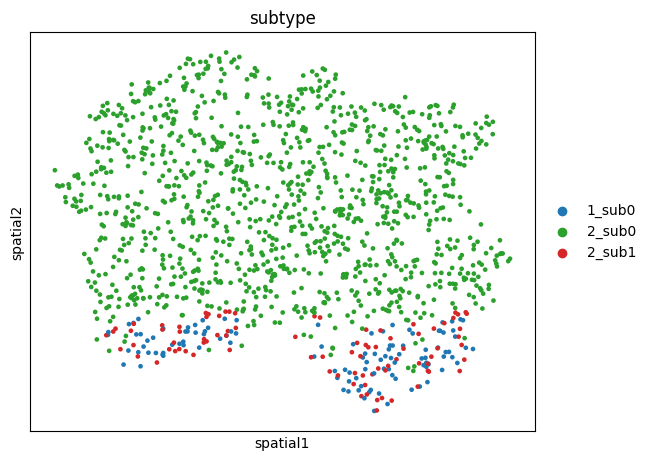

Slice 1: 86/87 sub1 cells receiving (98.85 %).


/opt/conda/envs/attn/lib/python3.9/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


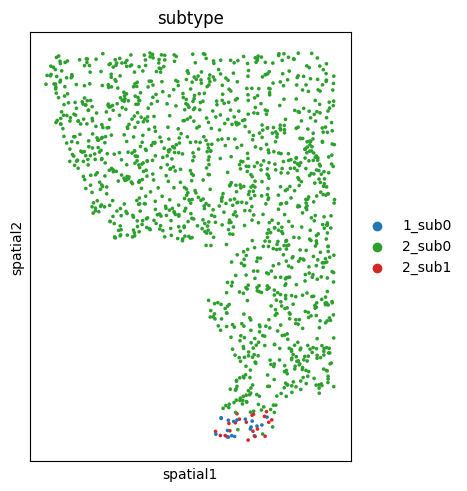

Slice 2: 19/21 sub1 cells receiving (90.48 %).


/opt/conda/envs/attn/lib/python3.9/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


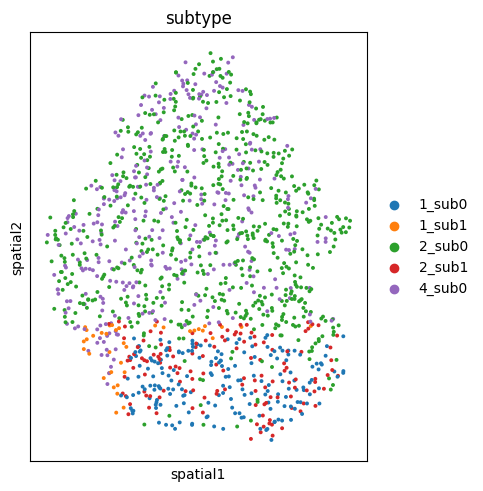

Slice 3: 167/170 sub1 cells receiving (98.24 %).


/opt/conda/envs/attn/lib/python3.9/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


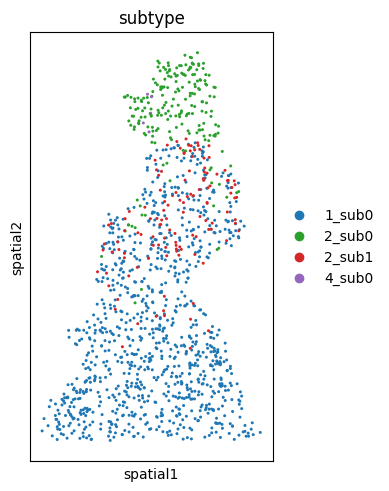

Slice 4: 122/122 sub1 cells receiving (100.00 %).


/opt/conda/envs/attn/lib/python3.9/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


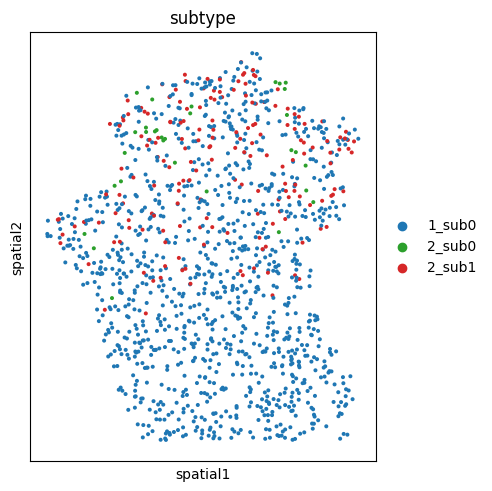

Slice 5: 172/173 sub1 cells receiving (99.42 %).


/opt/conda/envs/attn/lib/python3.9/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


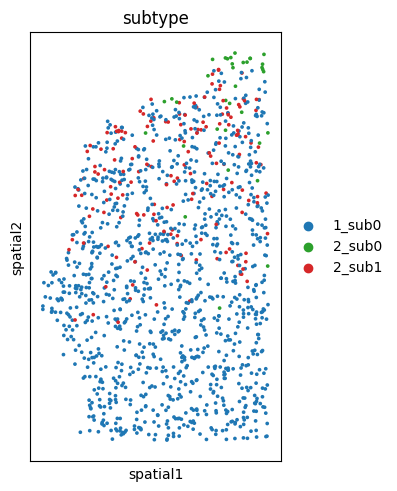

Slice 6: 162/162 sub1 cells receiving (100.00 %).


/opt/conda/envs/attn/lib/python3.9/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


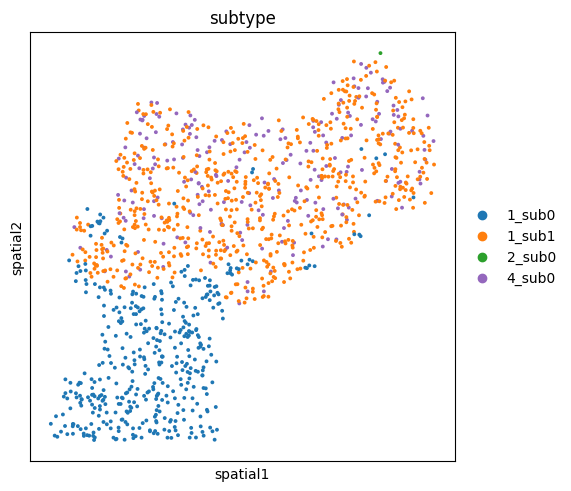

Slice 7: 587/591 sub1 cells receiving (99.32 %).


/opt/conda/envs/attn/lib/python3.9/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


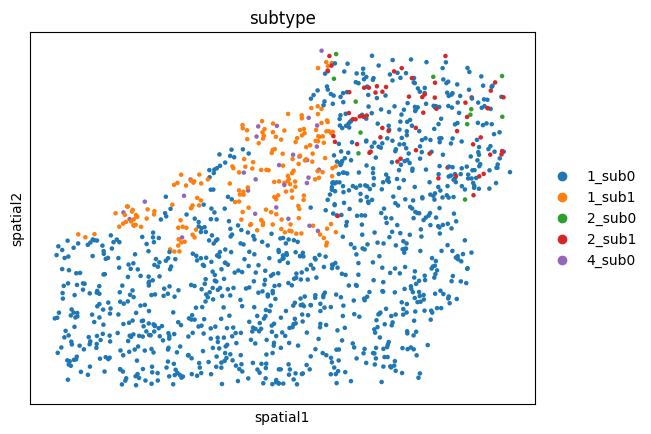

Slice 8: 250/253 sub1 cells receiving (98.81 %).


/opt/conda/envs/attn/lib/python3.9/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


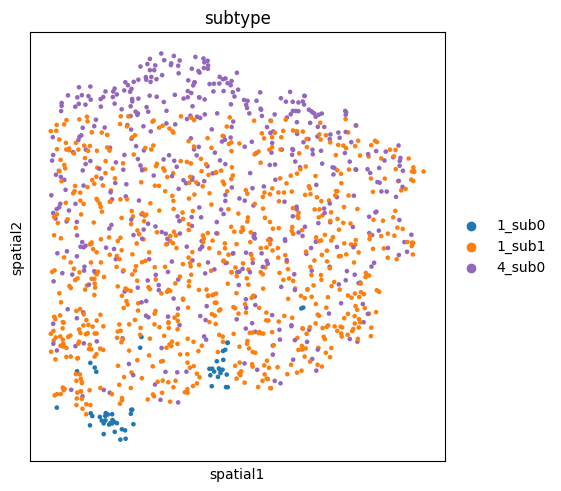

Slice 9: 700/702 sub1 cells receiving (99.72 %).


/opt/conda/envs/attn/lib/python3.9/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


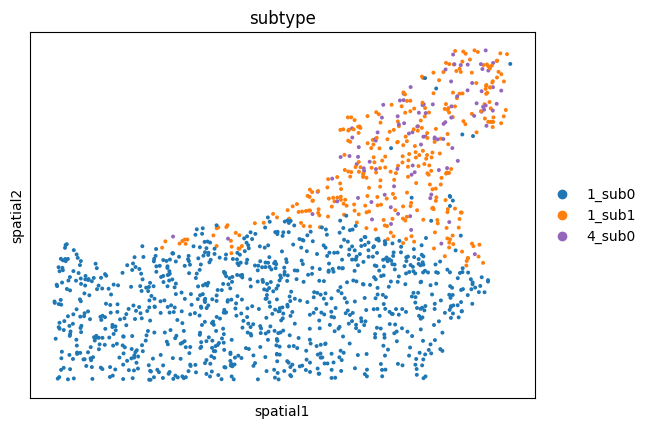

Slice 10: 308/317 sub1 cells receiving (97.16 %).


/opt/conda/envs/attn/lib/python3.9/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


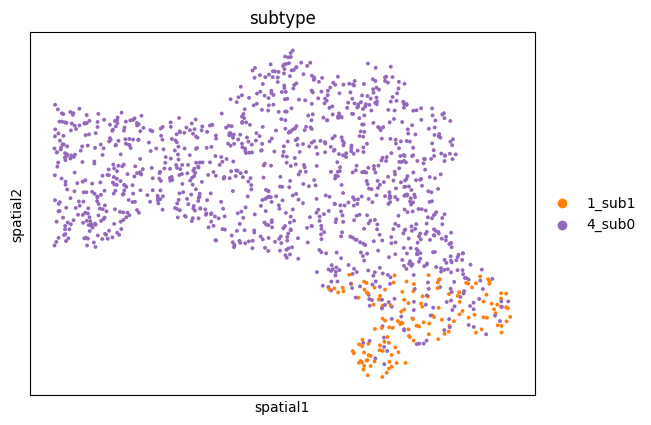

Slice 11: 137/141 sub1 cells receiving (97.16 %).


/opt/conda/envs/attn/lib/python3.9/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


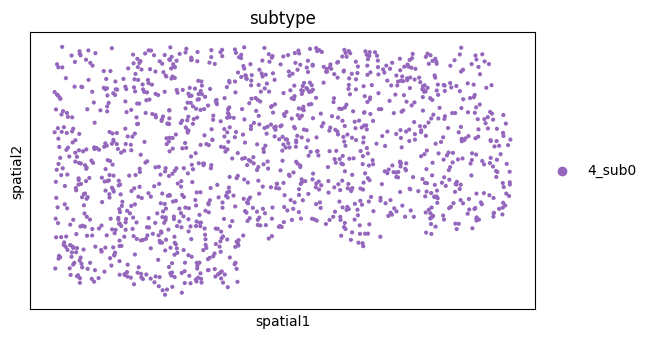

Slice 12: 0/0 sub1 cells receiving (0.00 %).


/opt/conda/envs/attn/lib/python3.9/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


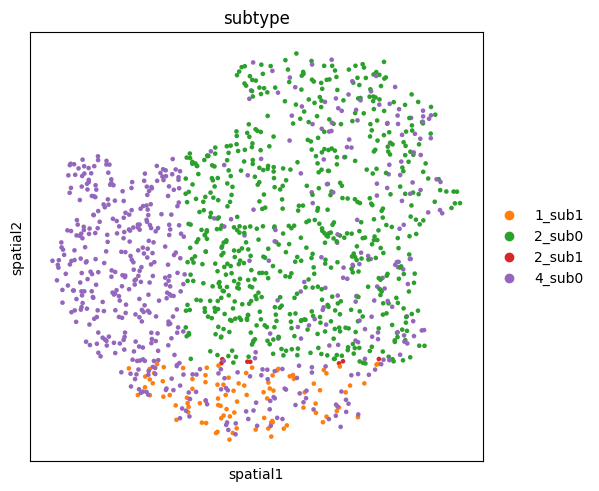

Slice 13: 102/102 sub1 cells receiving (100.00 %).


/opt/conda/envs/attn/lib/python3.9/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


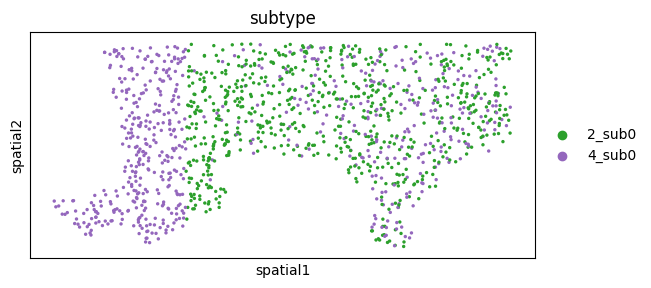

Slice 14: 0/0 sub1 cells receiving (0.00 %).

Overall: 2452/2469 sub1 cells receiving (99.31 %).


In [ ]:
# ------------------------------------------------------------------
# accumulators across all slices
receiving_sub1_global = set()
all_sub1_global       = set()

for i in range(len(graph_data)):

    graph_idx = i
    subset    = adata[graph_data[graph_idx].idx.numpy()]
    coords    = subset.obsm["spatial"].astype(float)              # (n_slice, 2)

    sq.pl.spatial_scatter(subset, color="subtype", img=False, size=5)
    plt.show()

    # ---------- slice-level helpers --------------------------------
    subtypes   = subset.obs["subtype"].astype(str)
    prefixes   = subtypes.str.split("_").str[0]
    idx_map    = dict(enumerate(subset.obs_names))                # local → global

    # prefix → list[local idx]
    prefix_to_loc = {}
    for loc, p in enumerate(prefixes):
        prefix_to_loc.setdefault(p, []).append(loc)

    # -------- filter interaction rows to this slice ----------------
    slice_prefix_set = set(prefixes)
    interact = (
        interaction_df
        .query("interaction_type == 'interaction'")
        .dropna(subset=["sender_cell"])
        .assign(sender_cell=lambda d: d.sender_cell.astype(int).astype(str))
        .loc[lambda d:
              d.receptor_subtype.isin(subtypes) &
              d.sender_cell.isin(slice_prefix_set)]
    )

    # -------- mark sub 1 receivers in this slice -------------------
    receiving_sub1_slice = set()
    for s_pref, r_st, R in interact[["sender_cell",
                                     "receptor_subtype",
                                     "radius_of_effect"]].itertuples(index=False):

        send_loc = prefix_to_loc.get(s_pref, [])
        recv_loc = np.where(subtypes == r_st)[0]                   # array

        if not send_loc or recv_loc.size == 0:
            continue

        # coords of senders and receptors
        s_xy = coords[send_loc]                                   # (|S|, 2)
        r_xy = coords[recv_loc]                                   # (|R|, 2)

        # pairwise distances sender↔receptor   (|S|, |R|)
        # broadcasting shape fix: [:, None, :] vs [None, :, :]
        dists = np.linalg.norm(s_xy[:, None, :] - r_xy[None, :, :], axis=-1)

        # receptors that have any sender within R
        recv_hits = recv_loc[(dists <= R).any(axis=0)]
        receiving_sub1_slice.update(idx_map[rl] for rl in recv_hits)

    # collect all sub1 in this slice (for denominator)
    sub1_loc        = np.where(subtypes.str.endswith("sub1"))[0]
    all_sub1_slice  = {idx_map[loc] for loc in sub1_loc}

    # ---------- per-slice report -----------------------------------
    tot = len(all_sub1_slice)
    rec = len(receiving_sub1_slice)
    pct = 0.0 if tot == 0 else 100.0 * rec / tot
    print(f"Slice {graph_idx}: {rec}/{tot} sub1 cells receiving "
          f"({pct:.2f} %).")

    # ---------- update global sets ---------------------------------
    receiving_sub1_global.update(receiving_sub1_slice)
    all_sub1_global.update(all_sub1_slice)

# ------------------------------------------------------------------
# Grand total across all slices
n_total = len(all_sub1_global)
n_recv  = len(receiving_sub1_global)
if n_total == 0:
    print("No sub1 cells found in the whole dataset.")
else:
    pct = 100.0 * n_recv / n_total
    print(f"\nOverall: {n_recv}/{n_total} sub1 cells receiving "
          f"({pct:.2f} %).")


In [ ]:
positive_rules = (
    interaction_df
    .query("interaction_type == 'interaction'")
    .loc[:, ["sender_cell", "receptor_subtype"]]  # keep only what we need
    .dropna()                                     # just in case
)
positive_rules["sender_cell"] = positive_rules["sender_cell"].astype(int).astype(str)  # convert to str for matching
positive_edges_count = 0
edges_count = 0
for data in graph_data:
    edge_index   = data.edge_index.cpu().numpy()
    node_indices = data.idx.cpu().numpy()

    subtypes_all = adata.obs["subtype"].to_numpy()
    node_subtypes = subtypes_all[node_indices]

    src_subtypes = node_subtypes[edge_index[0]]        # e.g. '4_sub0'
    tgt_subtypes = node_subtypes[edge_index[1]]        # e.g. '2_sub1'

    edges_df = pd.DataFrame({
        "sender_cell": [s.split("_")[0] for s in src_subtypes],  # keep only the number
        "receptor_subtype": tgt_subtypes,
    })

    matches = edges_df.merge(
        positive_rules,
        how="inner",
        on=["sender_cell", "receptor_subtype"],
    )

    positive_edges_count += len(matches)
    edges_count += len(edges_df)    
tau_init = positive_edges_count / edges_count
print(f"tau init: {tau_init}")


tau init: 0.05583892432908051


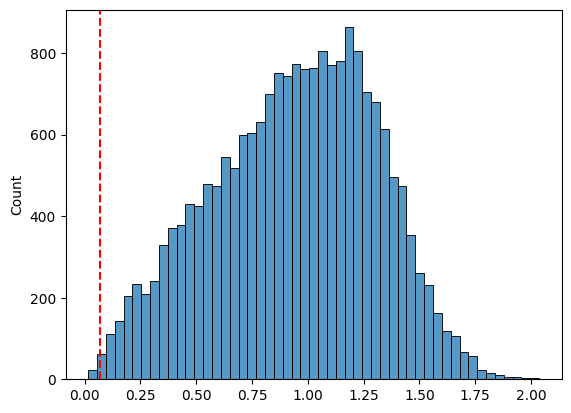

In [ ]:
sns.histplot(graph_data[1].edge_attr)
plt.axvline(0.07, color='red', linestyle='--')

In [ ]:
# from matplotlib.colors import ListedColormap
# import seaborn as sns

# all_idx = np.concatenate([batch.idx.cpu().numpy() for batch in train_dl])

# subtype_series = adata.obs["subtype"].iloc[all_idx].astype(str)  # (len(all_idx),)
# unique_subtypes = np.sort(subtype_series.unique())               # stable order

# palette = sns.color_palette("tab10", n_colors=len(unique_subtypes))
# cmap    = ListedColormap(palette)                                # for scatter
# subtype_to_int = {s: i for i, s in enumerate(unique_subtypes)}   # str → int

# plt.figure(figsize=(8, 8))

# for batch in graph_data:
#     idx      = batch.idx.cpu().numpy()
#     coords   = adata.obsm["spatial"][idx]                        # (B, 2)

#     subtypes = adata.obs["subtype"].iloc[idx].astype(str).values # (B,)
#     int_codes = np.vectorize(subtype_to_int.get)(subtypes)       # (B,) ints

#     plt.scatter(coords[:, 0], coords[:, 1],
#                 c=int_codes, cmap=cmap,
#                 vmin=-0.5, vmax=len(unique_subtypes) - 0.5,
#                 s=10, alpha=0.7, linewidth=0)
#     plt.gca().invert_yaxis()

#     plt.title("Cells coloured by sub-type")
#     plt.xlabel("x"); plt.ylabel("y")

#     handles = [
#         plt.Line2D([], [], marker='o', linestyle='',
#                 color=palette[i], label=label, markersize=6)
#         for i, label in enumerate(unique_subtypes)
#     ]
#     plt.legend(handles=handles, title="Sub-type",
#             bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.)
#     plt.tight_layout()
#     plt.show()


<Axes: ylabel='Count'>

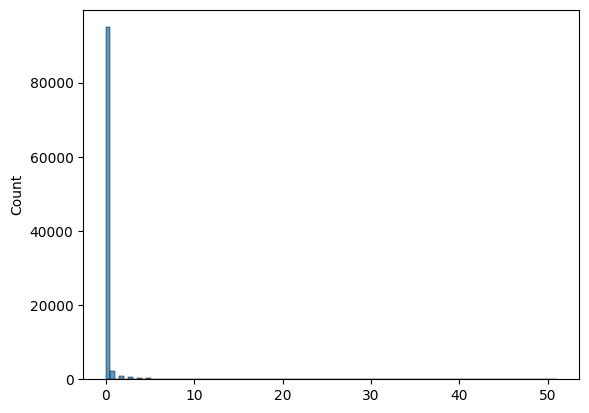

In [ ]:
genes = adata.X.toarray().flatten()
idx = np.arange(len(genes))
np.random.shuffle(idx)
idx = idx[:100000] 

sns.histplot(genes[idx], bins=100)

In [ ]:
graph_data[1].cluster.unique()

tensor([1, 2])

In [ ]:
graph_data[0].bulk_clu[2].max()

tensor(11.4221)

In [ ]:
edges=0
for i in graph_data:
    edges += i.edge_attr.shape[0]
edges

293472

In [99]:
graph_data[0].bulk_clu.max()

tensor(15.6344)

In [100]:
from importlib import reload

pyro.clear_param_store()
reload(scKI)

# pyro.util.set_rng_seed(0)                      # reproducible drifts
# pyro.enable_validation(True)                   # NaNs / shape bugs
# torch.autograd.set_detect_anomaly(True)        # exploding grads


cfg = scKI.Config(
    c_in=adata.shape[-1], 
    num_clusters=adata.obs['leiden'].astype(int).max()+1,
    n_epochs=150,
    act=torch.nn.LeakyReLU(),
    lr=1e-3,
    # log_tau_loc=np.log(tau_init),  
    # log_tau_scale=1,  
    # device='cpu'
    device='cuda' if torch.cuda.is_available() else 'cpu',
    )
model = scKI.scKI(cfg)
tl, vl, r2 = model.fit(train_dl, val_dl)

E150  trainELBO=816.337  valELBO=816.118  R²=0.742 v=-1.74 pi 25, 95 = 0.000 0.035 hsic=0.174 0.292 ent=0.316 penalty=5.176e-01: 100%|██████████| 150/150 [02:38<00:00,  1.06s/it]    


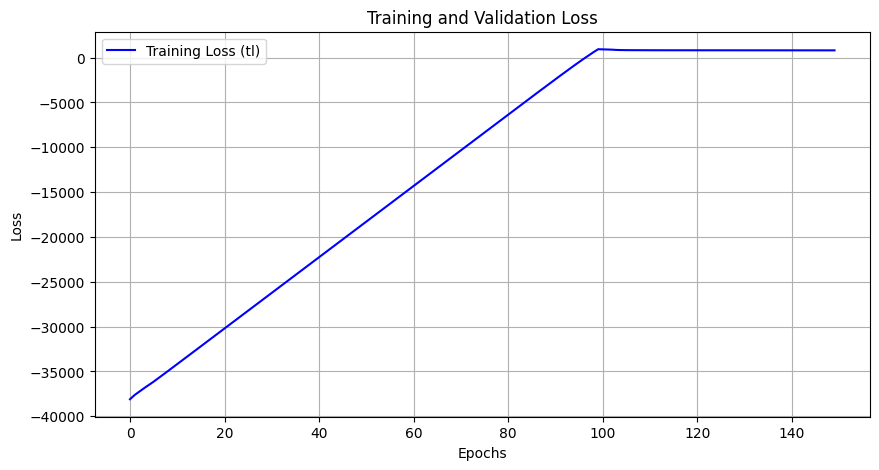

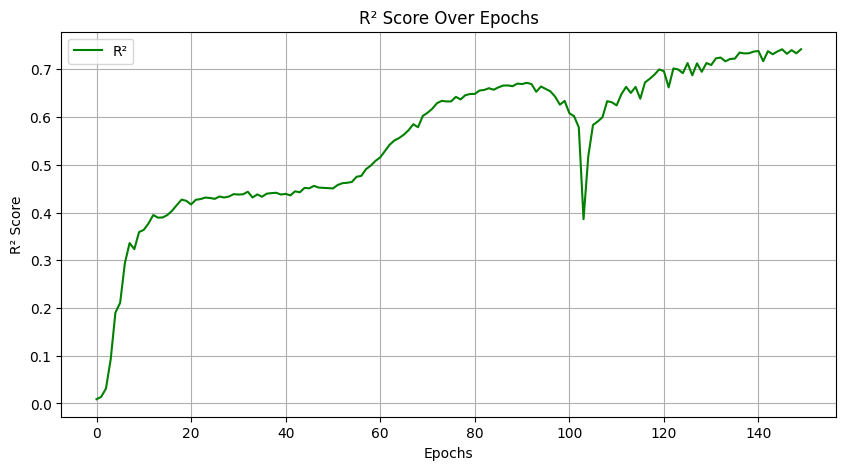

In [101]:
# Plot tl and vl
tl = np.array(tl)
tl_plot = tl[np.where(np.isnan(tl) == False)]
# tl_plot = tl_plot[tl_plot < np.quantile(tl_plot,0.95)]
# tl_plot = tl_plot[50:]
plt.figure(figsize=(10, 5))
plt.plot(tl_plot, label='Training Loss (tl)', color='blue')
# plt.plot(vl, label='Validation Loss (vl)', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot r2
plt.figure(figsize=(10, 5))
plt.plot(r2, label='R²', color='green')
plt.xlabel('Epochs')
plt.ylabel('R² Score')
plt.title('R² Score Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [89]:
val_data = dataset.XeniumDataset(
    adatas=[adata], 
    n_subgraphs=1, 
    k=k,
    is_weighted=True,
    sigma=sigma,
)

/opt/conda/envs/attn/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


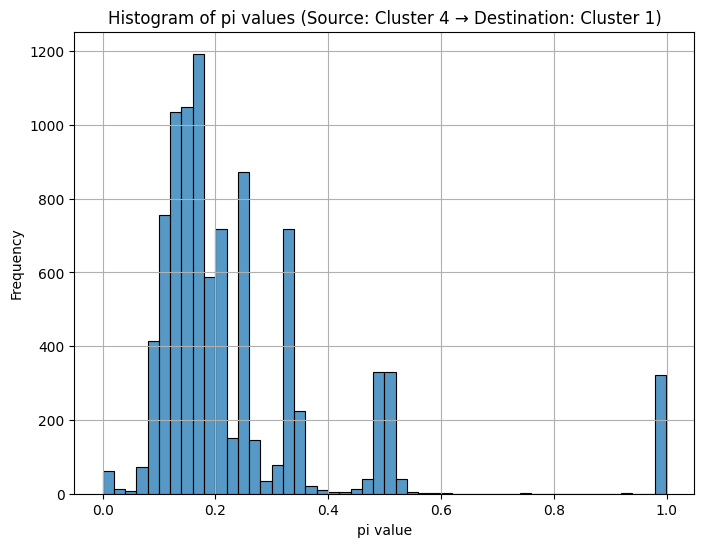

In [91]:
# Filter edge_df for source cluster 4 and destination cluster 1
filtered_pi = edge_df[
    (edge_df['source_subtype'].str.startswith('4')) &
    (edge_df['target_subtype'].str.startswith('1'))
]['pi_value']

# Plot the histogram
plt.figure(figsize=(8, 6))
sns.histplot(filtered_pi, bins=50, kde=False)
plt.title("Histogram of pi values (Source: Cluster 4 → Destination: Cluster 1)")
plt.xlabel("pi value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

/opt/conda/envs/attn/lib/python3.9/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


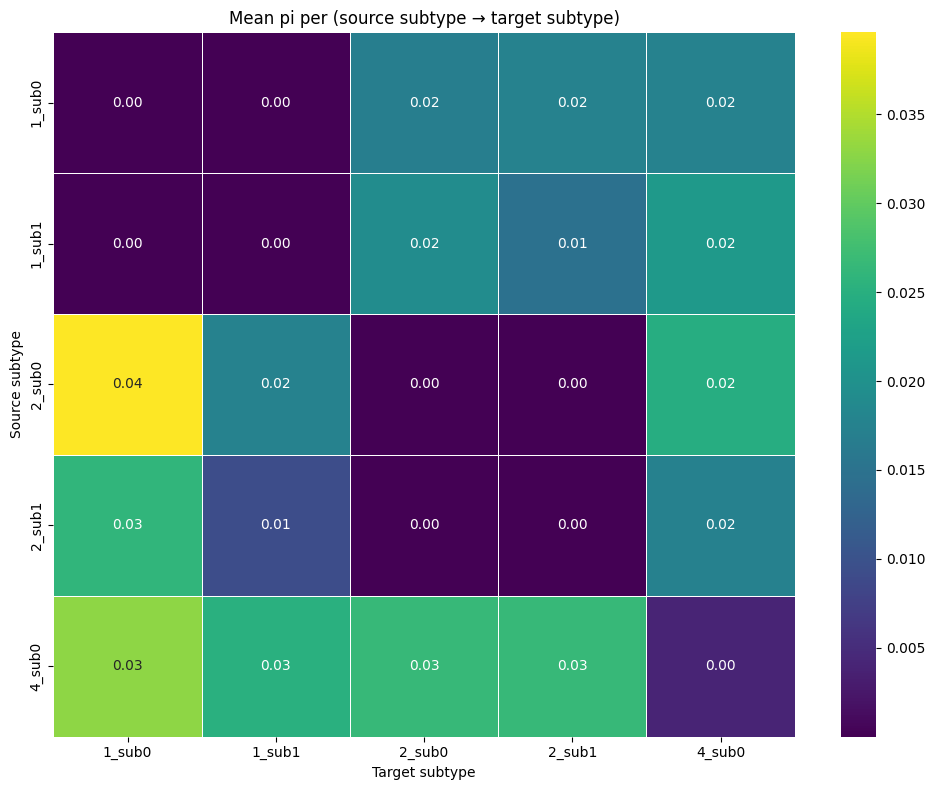

In [102]:
params = model.get_params(val_data)

pi = params['pi'].detach().cpu().numpy()        # (E,)
edge_index = val_data[0].edge_index.cpu().numpy()  # (2, E)

node_indices = val_data[0].idx.cpu().numpy()       # (N,)  mapping to adata rows
subtypes_all = adata.obs['subtype'].to_numpy()     # (n_cells,)

node_subtypes = subtypes_all[node_indices]         # (N,)  subtype per graph node

# source / target subtype for every edge
src_sub = node_subtypes[edge_index[0]]             # (E,)
tgt_sub = node_subtypes[edge_index[1]]             # (E,)

edge_df = pd.DataFrame({
    'source_subtype': src_sub,
    'target_subtype': tgt_sub,
    'pi_value':   pi
})

heatmap_data = (
    edge_df
    .groupby(['source_subtype', 'target_subtype'])['pi_value']
    .mean()
    .unstack(fill_value=0)
    .sort_index(axis=0)
    .sort_index(axis=1)
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_data,
    annot=True, fmt=".2f", cmap="viridis",
    linewidths=.5, linecolor='white'
)
plt.title("Mean pi per (source subtype → target subtype)")
plt.xlabel("Target subtype")
plt.ylabel("Source subtype")
plt.tight_layout()
plt.show()


<Axes: ylabel='Count'>

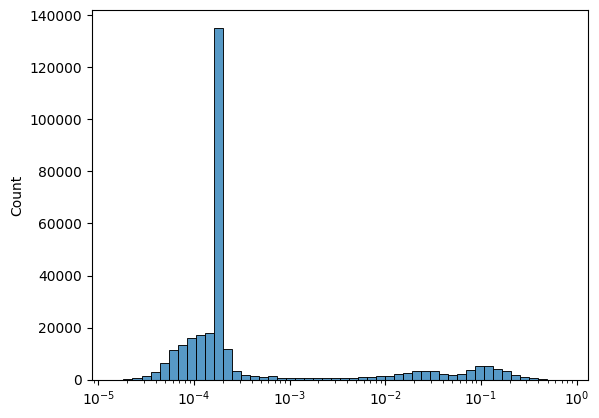

In [85]:
sns.histplot(params['pi'].flatten(), bins=50, log_scale=True)

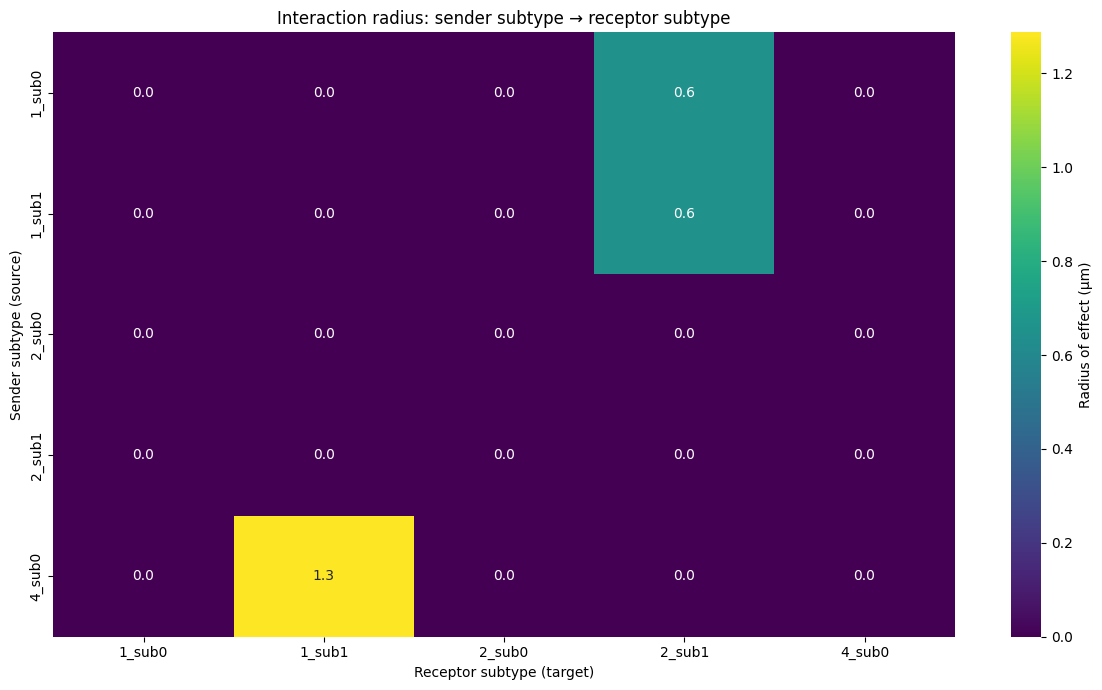

In [21]:
import re
from collections import defaultdict

# ── 1.  interaction table ---------------------------------------------------
interaction_df = interaction_df.copy()

# convert 4.0  →  "4"  (and leave NaNs alone)
interaction_df["sender_cell"] = (
    interaction_df["sender_cell"]
        .astype(str)                       # e.g. "4.0", "nan"
        .str.replace(r"\.0+$", "", regex=True)
)

interaction_df["receptor_subtype"] = interaction_df["receptor_subtype"].astype(str)
interaction_df["radius_of_effect"] = interaction_df["radius_of_effect"].fillna(0)/edge_median

# ── 2.  harvest every subtype & build mapping ------------------------------
pat = re.compile(r"\d+_sub\d+")
all_subtypes = (
    adata.obs["subtype"].astype(str)
        .apply(pat.findall)               # list per row
        .explode().dropna().unique()
)

cell_to_subtypes = defaultdict(list)
for st in all_subtypes:
    cell_to_subtypes[st.split("_")[0]].append(st)   # "4_sub1" → key "4"

# ── 3.  expand sender IDs to sender-subtypes --------------------------------
rows = []
for _, row in interaction_df.iterrows():
    sid = row["sender_cell"]
    if sid == "nan" or sid not in cell_to_subtypes:
        continue
    for ssub in cell_to_subtypes[sid]:
        rows.append({
            "sender_subtype"   : ssub,
            "receptor_subtype" : row["receptor_subtype"],
            "radius_of_effect" : row["radius_of_effect"],
        })

interaction_expanded = pd.DataFrame(rows)

# ── 4.  pivot to a full matrix ---------------------------------------------
heatmap_data = (
    interaction_expanded
        .pivot_table(index="sender_subtype",
                     columns="receptor_subtype",
                     values="radius_of_effect",
                     aggfunc="max",
                     fill_value=0)
        .reindex(index   = sorted(all_subtypes),
                 columns = sorted(all_subtypes),
                 fill_value = 0)
        .astype(float)
)

# ── 5.  plot ---------------------------------------------------------------
plt.figure(figsize=(12, 7))
sns.heatmap(heatmap_data, cmap="viridis", annot=True, fmt=".1f",
            cbar_kws=dict(label="Radius of effect (µm)"))
plt.title("Interaction radius: sender subtype → receptor subtype")
plt.xlabel("Receptor subtype (target)")
plt.ylabel("Sender subtype (source)")
plt.tight_layout()
plt.show()


In [ ]:
px.shape

(50000,)

In [ ]:
import torch.distributions as dist
theta = pyro.get_param_store()['theta'].detach().cpu()  # (E,)
mu = params['px'].detach().cpu()

logits = np.log(mu) - np.log(theta)
pred_dist = dist.NegativeBinomial(total_count=theta, logits=logits)
pred = pred_dist.sample()

# Compute R^2
r2 = r2_score(adata_X.flatten(), pred.flatten())
print(r2)

0.42209696769714355


In [ ]:
import pyro.poutine as poutine
from pyro.optim import Adam
import torch.nn.functional as F

preds, targs   = [], []
for batch in train_dl:
    batch = batch.to(model.device)

    g_tr  = poutine.trace(model.guide).get_trace(batch)
    m_tr  = poutine.trace(
                poutine.replay(model.model, trace=g_tr)
            ).get_trace(batch)
    v_mu  = m_tr.nodes["v"]["value"]
    lib   = batch.x.sum(-1, keepdim=True)
    px    = F.softmax(model.decoder(v_mu), -1) * lib
    

    preds.append(px.cpu())
    targs.append(batch.x.cpu())

r2 = r2_score(torch.cat(targs).detach().numpy().flatten(),
                torch.cat(preds).detach().numpy().flatten())

print(r2)

0.7534645795822144


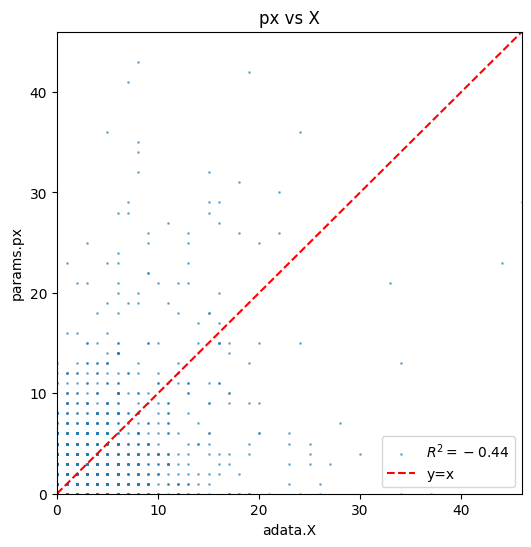

In [ ]:
adata_X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X

# Compute R^2
r2 = r2_score(adata_X.flatten(), pred.flatten())

idx = np.arange(adata_X.shape[0])
np.random.shuffle(idx)
ground_truth = adata_X[idx[:100]]
pred = pred[idx[:100]]
ground_truth = ground_truth.flatten()
px = pred.flatten()

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(ground_truth, px, alpha=0.5, s=1, label=f"$R^2 = {r2:.2f}$")
plt.plot([ground_truth.min(), ground_truth.max()], [ground_truth.min(), ground_truth.max()], color='red', linestyle='--', label="y=x")
plt.xlabel("adata.X")
plt.ylabel("params.px")
plt.xlim(ground_truth.min(), ground_truth.max())
plt.ylim(ground_truth.min(), ground_truth.max())
plt.legend()
plt.title("px vs X")
plt.show()

/opt/conda/envs/attn/lib/python3.9/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


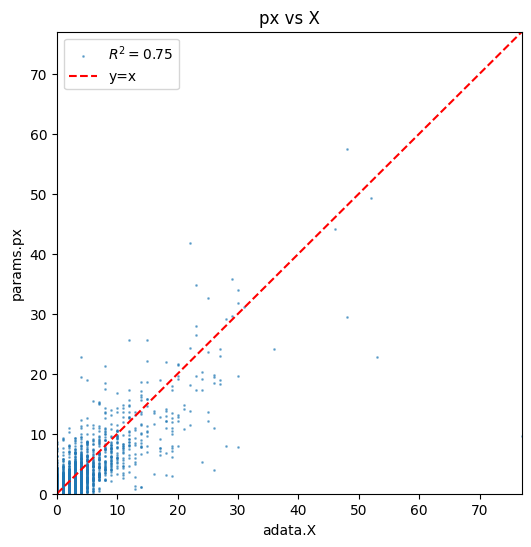

In [ ]:
from sklearn.metrics import r2_score


params = model.get_params(val_data)

# Extract data
px = params['px'].detach().cpu().numpy()
adata_X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X

# Compute R^2
r2 = r2_score(adata_X.flatten(), px.flatten())

idx = np.arange(adata_X.shape[0])
np.random.shuffle(idx)
ground_truth = adata_X[idx[:100]]
px = px[idx[:100]]
ground_truth = ground_truth.flatten()
px = px.flatten()

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(ground_truth, px, alpha=0.5, s=1, label=f"$R^2 = {r2:.2f}$")
plt.plot([ground_truth.min(), ground_truth.max()], [ground_truth.min(), ground_truth.max()], color='red', linestyle='--', label="y=x")
plt.xlabel("adata.X")
plt.ylabel("params.px")
plt.xlim(ground_truth.min(), ground_truth.max())
plt.ylim(ground_truth.min(), ground_truth.max())
plt.legend()
plt.title("px vs X")
plt.show()